In [1]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import h5py
import importlib
from skyfield.api import load, EarthSatellite, Topos, wgs84

BDC is using numpy


In [2]:
day = '10_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_24'

In [3]:
with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    c_acclen = config["correlation"]["coarse_acclen"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]

print("Antenna Paths:", dir_parents)
print("Antenna Coordinates:", coords)
print("Visibility Accumulation Length", v_acclen)
print("Coarse Accumulation Length:", c_acclen)
print(global_start_time)

Antenna Paths: ['/project/s/sievers/albatros/mars/202307/baseband/stn_1_central', '/project/s/sievers/albatros/mars/202307/baseband/stn_2_east']
Antenna Coordinates: [[79.41718333333333, -90.76735, 189], [79.41721666666666, -90.75885, 176]]
Visibility Accumulation Length 30000
Coarse Accumulation Length: 1000000
1699593012


In [4]:
ref_coords = coords[0]
a2_coords = coords[1]

ref_path = dir_parents[0]
a2_path = dir_parents[1]

C_T_ACCLEN = c_acclen* T_SPECTRA
V_T_ACCLEN = v_acclen* T_SPECTRA

c_nchunks = int((visibility_window)/C_T_ACCLEN)
v_nchunks = int((visibility_window)/V_T_ACCLEN)

tle_path = outils.get_tle_file(global_start_time, "/project/s/sievers/mohanagr/OCOMM_TLES")
#tle_path2 = outils.get_tle_file(global_start_time2, "/project/s/sievers/mohanagr/OCOMM_TLES")


context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(context)
print(global_start_time)

[1000, 1.6384e-05, 30000, 2034, [79.41718333333333, -90.76735, 189]]
1699593012


<p style="color: blue; font-size: 25px;">Unpack All Pulses</p>


In [5]:
pulse_data = []


#with h5py.File(f'vis_all_{global_start_time}_10hrs.h5', 'r') as f:

with h5py.File(f'{working_directory}/{bits}bit/{day}/visraw_bline{baseline_idx}_{global_start_time}.h5', 'r') as f:
    for p in f:
        pulse_info = []
        pulse_info.append(p) #index 0
        pulse_info.append([int(f[p].attrs['start_time']), int(f[p].attrs['end_time']), int(f[p].attrs['global_start_time'])]) # index 1
        pulse_info.append(json.loads(f[p].attrs['sats'])) #index 2
        #pulse_info.append(f[p].attrs['tle_path']) #index 3
        pulse_info.append(outils.get_tle_file(int(f[p].attrs['global_start_time']) + int(f[p].attrs['start_time']), "/project/s/sievers/mohanagr/OCOMM_TLES"))
        pulse_info.append(f[f'/{p}'][:])  # index 4
        pulse_data.append(pulse_info)

for pulse in pulse_data:
    print(pulse)
print(len(pulse_data))

#note on ordering of the pulse_data list:

# example entry:   [[relative_start_time, relative_end_time, global_start_time], {satID:[chan1, chan2]}, tle_path, [observed data array]]

['0_1000', [1000, 1220, 1699593012], {'33591': [1850]}, '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt', array([[-0.02366487-0.0127756j , -0.02083885+0.00324622j,
         0.01895399-0.00659714j, ..., -0.0081681 +0.01361346j,
        -0.09944   -0.12181748j, -0.00753918+0.02220012j],
       [ 0.0034557 -0.01183325j,  0.0070162 -0.02314254j,
         0.02565563+0.0103672j , ..., -0.01183286-0.01455589j,
        -0.08082044-0.18759072j, -0.00869166-0.0013613j ],
       [-0.02125771-0.0036649j ,  0.01026246-0.00020942j,
        -0.0021991 -0.00408399j, ..., -0.00513055-0.01162377j,
        -0.02638835-0.14960083j, -0.02136234+0.00335099j],
       ...,
       [-0.00062832+0.00565472j,  0.00712073+0.01382238j,
        -0.00764452+0.00680655j, ..., -0.01832568+0.01916322j,
        -0.01602193-0.01120484j,  0.01214736-0.00963415j],
       [ 0.02544594-0.00387461j, -0.00942473+0.00439809j,
        -0.01078607-0.02083858j, ..., -0.0048171 -0.00125662j,
        -0.0075398 -0.00

<p style="color: blue; font-size: 25px;">Filter for Good Pulses</p>


Need to automate for v2

In [6]:
info_dict = {}

In [7]:
good_idx_set = set({})

In [8]:
channel_list = np.arange(1834, 1852, dtype=int)
print(channel_list[2])

1836


DONT TOUCH THE ABOVE PART!!

In [9]:
importlib.reload(ch)

<module 'coord_helper' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/coord_helper.py'>

start a loop here for pulse index.

In [28]:
pulse_idx = 2
print(pulse_data[pulse_idx][0])
print(pulse_data[pulse_idx][2])

11_37890
{'33591': [1849, 1850]}


In [29]:
#unpack info for single pulse
label = pulse_data[pulse_idx][0]
times = pulse_data[pulse_idx][1]
satID = int(list(pulse_data[pulse_idx][2].keys())[0])  #for now only worry about one satellite
channels_present = list(pulse_data[pulse_idx][2].values())[0]
tle_path = pulse_data[pulse_idx][3]

#here I might want to interpolate in v2?
phased_visibility = np.angle(pulse_data[pulse_idx][4])


print(label)
print(times)
print(satID)
print(channels_present)
print(tle_path)

11_37890
[37890, 38410, 1699593012]
33591
[1849, 1850]
/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt


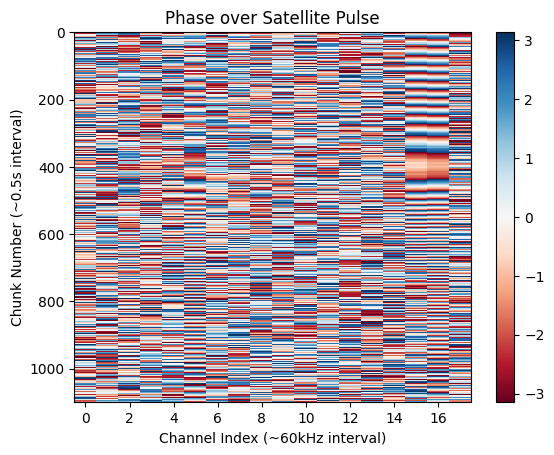

In [30]:
plt.xlabel("Channel Index (~60kHz interval)")
plt.ylabel("Chunk Number (~0.5s interval)")
plt.title("Phase over Satellite Pulse")
plt.imshow(phased_visibility, aspect='auto',cmap='RdBu',interpolation="none")
plt.colorbar()

WITH ROWS

In [31]:
np.where(channel_list)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17]),)

In [38]:
sats_present = [int(np.where(chan==channel_list)[0][0]) for chan in channels_present]
print(sats_present)
noise_chans = np.setdiff1d(np.arange(18), sats_present)
print(noise_chans)

[15, 16]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 17]


In [52]:
column_noise = []
column_data = []
for idx in noise_chans:
    column_data.append(phased_visibility[:, idx])
std = np.std(np.real(column_data))
print(std)

1.816042909002963


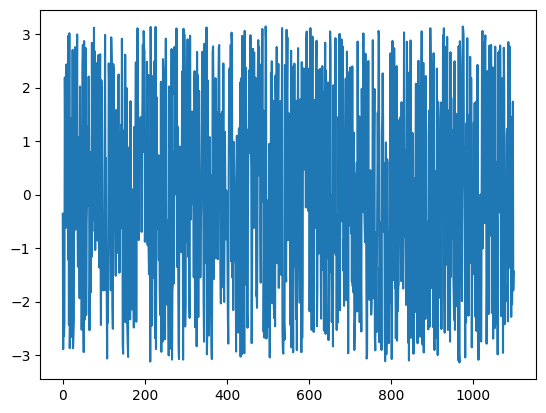

In [56]:
plt.plot(phased_visibility[:,0])

In [57]:
print("initial duration", times[1]-times[0])
print("corresponds to chunks:", (times[1]-times[0]) / (context[2]*context[1]))
print(channels_present)

initial duration 520
corresponds to chunks: 1057.9427083333333
[1849, 1850]


In [58]:
chan_small = 16
chan_big = int(channel_list[chan_small])
print("big chan idx:", chan_big)

big chan idx: 1850


-2.6480913917613114
0.0


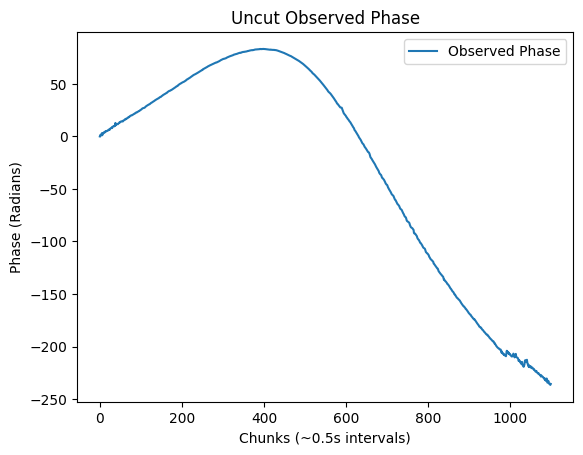

In [59]:
phase_data = np.unwrap(phased_visibility[ : , chan_small] - phased_visibility[0, chan_small])

print(phased_visibility[0, chan_small])
print(phase_data[0])

plt.plot(phase_data, label="Observed Phase")
plt.xlabel("Chunks (~0.5s intervals)")
plt.ylabel("Phase (Radians)")
plt.title("Uncut Observed Phase")
plt.legend()

duration in chunks: 350
duration in seconds: 172.032
0.0


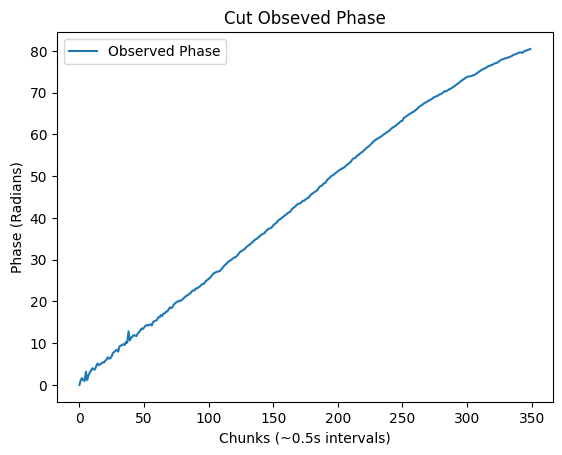

In [60]:
shift_c = 0
duration_c = 350

# should this be ceil or int?
duration_s = duration_c * (context[2]*context[1])
shift_s = shift_c * (context[2]*context[1])
print('duration in chunks:', duration_c)
print('duration in seconds:', duration_s)

phase_data = np.unwrap(phased_visibility[shift_c :  duration_c + shift_c, chan_small] - phased_visibility[shift_c, chan_small])
print(phase_data[0])


plt.plot(phase_data, label="Observed Phase")
plt.xlabel("Chunks (~0.5s intervals)")
plt.ylabel("Phase (Radians)")
plt.title("Cut Obseved Phase")
plt.legend()

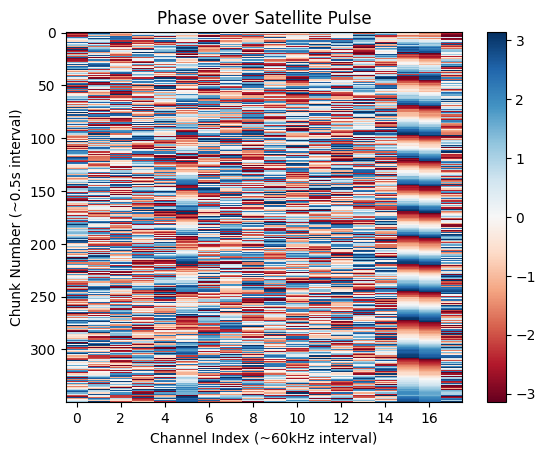

In [64]:
new_data = pulse_data[pulse_idx][4][shift_c : shift_c + duration_c, :]



In [929]:
new_start_time = times[0] + shift_s
print(new_start_time)
new_end_time =   times[0] + shift_s + duration_s

info_dict[label] = [label, [new_start_time, new_end_time, times[2]], [satID, chan_big], tle_path, phase_data]
print(info_dict[label][1])
print(info_dict[label][1][1] - info_dict[label][1][0])

78960.0
[78960.0, 79254.912, 1699593012]
294.9119999999966


['38_78960', [78960.0, 79254.912, 1699593012], [25338, 1841], '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt', array([ 0.00000000e+00, -1.43589310e-01, -2.14851031e-01, -2.61666573e-01,
       -2.99400687e-01, -4.94725995e-01, -6.29842477e-01, -7.46650198e-01,
       -9.21998688e-01, -1.03219085e+00, -1.20032759e+00, -1.25413585e+00,
       -1.35385356e+00, -1.50699002e+00, -1.56704571e+00, -1.61577577e+00,
       -1.75089358e+00, -1.88610702e+00, -1.99365233e+00, -2.07565629e+00,
       -2.22457240e+00, -2.37720665e+00, -2.42684960e+00, -2.45228702e+00,
       -2.49600622e+00, -2.55691591e+00, -2.68720838e+00, -2.78188003e+00,
       -2.85631381e+00, -2.87103527e+00, -2.87643141e+00, -2.97413375e+00,
       -3.15839516e+00, -3.23165854e+00, -3.22917010e+00, -3.36829268e+00,
       -3.45078300e+00, -3.57608139e+00, -3.63125275e+00, -3.69455919e+00,
       -3.82741543e+00, -3.82286539e+00, -3.93265512e+00, -3.98899557e+00,
       -4.08923653e+00, -4.09206942e+00, -4.08

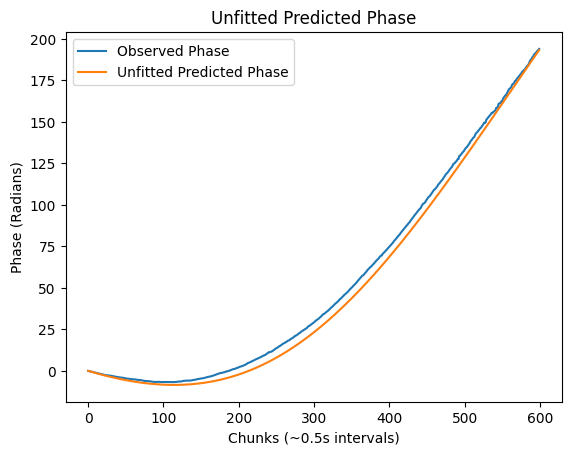

In [930]:
info_pulse = info_dict[label]
print(info_pulse)

plt.plot((info_pulse[4]), label="Observed Phase")
plt.plot(ch.phase_pred(a2_coords, 0, [info_pulse], context)[:len(info_pulse[4])], label="Unfitted Predicted Phase")
plt.xlabel("Chunks (~0.5s intervals)")
plt.ylabel("Phase (Radians)")
plt.title("Unfitted Predicted Phase")
plt.legend()

print("predictor chunk number", len(ch.phase_pred(a2_coords, 0, [info_pulse], context)))
print("observed chunk number", len(info_pulse[3]))

In [931]:
#good_idx_set.add(int(label.split('_')[0]))
good_idx_set.add(label)

# 14, 26, 40 a little sus (big gap, 33591)
# 17, 43 also a little sus (again big gap)
# 22 not great

print(good_idx_set)
print(len(good_idx_set))

{'21_55000', '37_75955', '12_38590', '35_74245', '0_1000', '22_56055', '20_51895', '34_72820', '24_57895', '10_36970', '16_44660', '32_68860', '38_78960', '1_1535', '18_48980', '27_62820', '13_39870', '17_45890', '11_37890', '19_50010'}
20


In [932]:
good_pulse_data = []
for label, info in info_dict.items():
    if label in good_idx_set:
        good_pulse_data.append(info)

In [933]:
print(len(pulse_data))

42


In [934]:
print(len(good_pulse_data))

20


In [935]:
print(good_pulse_data)

[['0_1000', [1000.0, 1172.032, 1699593012], [33591, 1850], '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231110.txt', array([  0.        ,   0.27780157,   0.51000743,   0.61862864,
         0.9203876 ,   1.2033146 ,   1.34294775,   1.62718565,
         1.78153519,   1.96166831,   1.89377365,   1.72430379,
         2.90335891,   3.12280053,   3.2289865 ,   3.46104782,
         3.60382421,   3.79603481,   4.03154729,   4.20219067,
         4.54014905,   4.81770443,   5.10435552,   5.18957964,
         5.5511369 ,   5.84295149,   6.07008478,   6.16759217,
         6.31868153,   6.64633073,   6.78723419,   7.08704805,
         7.34818622,   7.61035892,   7.9811646 ,   8.17298842,
         8.37602373,   8.65350292,   8.87260958,   9.22797045,
         9.41084631,   9.68650234,  10.01137201,  10.21948664,
        10.48367548,  10.87889476,  11.28636676,  11.46029489,
        11.77457236,  12.15220675,  12.49696251,  12.85939863,
        13.05161391,  13.40449197,  13.62955622,  13.89

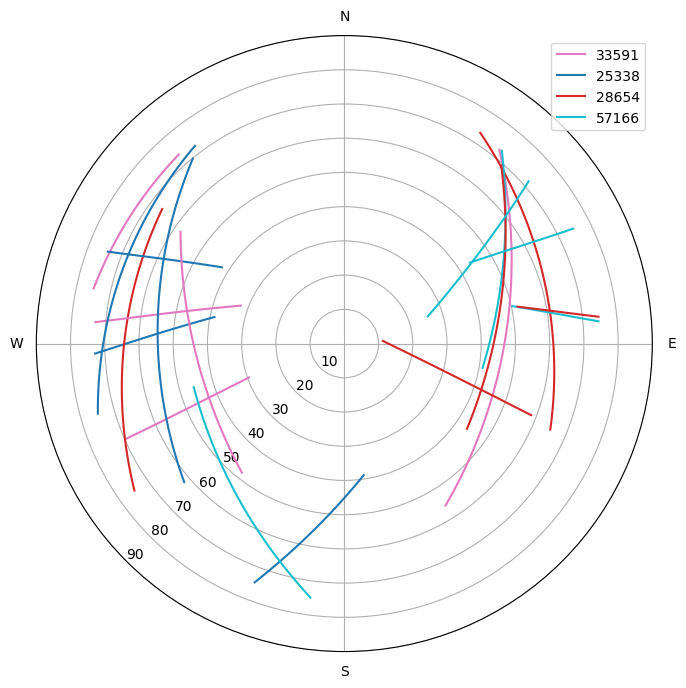

In [936]:
fig = ch.satpass_plotter(good_pulse_data, a2_coords)

In [937]:
with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_selected_bline_{baseline_idx}_{global_start_time}.h5', 'w') as f:
    for idx in range(len(good_pulse_data)):
        #name the data after the label
        pulse_array = f.create_dataset(f'{good_pulse_data[idx][0]}', data=good_pulse_data[idx][4])

        pulse_array.attrs['start_time']        = good_pulse_data[idx][1][0]
        pulse_array.attrs['end_time']          = good_pulse_data[idx][1][1]
        pulse_array.attrs['global_start_time'] = good_pulse_data[idx][1][2]
        pulse_array.attrs['sat']               = good_pulse_data[idx][2][0]
        pulse_array.attrs['chan']              = good_pulse_data[idx][2][1]
        pulse_array.attrs['tle_path']          = good_pulse_data[idx][3]

    f.attrs["vis_window"] = visibility_window
    f.attrs["v_acclen"] = v_acclen
    f.attrs["T_SPECTRA"] = V_T_ACCLEN
    f.attrs["v_nchunks"] = v_nchunks
    f.attrs["ref_coords"] = ref_coords #necessary?
    f.attrs["baseline_idx"] = baseline_idx